<a href="https://colab.research.google.com/github/fur-ruf/data_analysis/blob/main/lab2_mashine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №2
## Кластеризация

Выполнила: Будюкова Полина (408326)

Группа: P3321

Преподаватель: Солодкая Мария Александровна


### Цель работы:
Изучить алгоритмы кластеризации на примере набора данных с керамическими образцами с их химическим составом.


### Задание:
1. Проанализировать предметную область и выбрать метрику оценки качества кластеризации.
  
  
2. Отобрать признаки.
3. Реализовать алгоритмы k-means++ и DBSCAN.
4. Проверить качество кластеризации по выбранной метрике.

## Минутка теории:

Разбить данные на группы (кластеры) так, чтобы объекты внутри группы были похожи, а из разных групп — разные. Это обучение без учителя.

Суть k++:

Разбить данные на K сферических кластеров, минимизируя расстояние от точек до центров кластеров.

Алгоритм

Инициализация:

- Первый центр — случайная точка
- Каждый следующий центр выбирается с вероятностью, пропорциональной квадрату расстояния до ближайшего существующего центра
- Шаг назначения: Каждая точка -> к ближайшему центру
- Шаг обновления: Центр -> среднее арифметическое точек кластера
- Повторять шаги 2-3, пока центры не перестанут меняться

Суть dbs:

Искать области с высокой плотностью точек, разделённые областями с низкой плотностью.

Алгоритм

Для каждой непосещённой точки:

- Найти всех соседей в радиусе
- Если соседей < заданного параметра -> точка шум
- Если ≥ заданного параметра -> основать новый кластер и рекурсивно добавить всех достижимых по плотности соседей

## Анализ предметной области

Ceramic.Name: name of ceramic types from Longquan and Jindgezhen

Part: a binary categorical variable ('Body' or 'Glaze')

Na2O:  percentage of Na2O (wt%)

MgO:  percentage of MgO (wt%)

Al2O3:  percentage of  AI2O3 (wt%)

SiO2:  percentage of SiO2 (wt%)

K2O:  percentage of  K2O (wt%)

CaO:  percentage of CaO (wt%)

TiO2:  percentage of TiO2 (wt%)

Fe2O3:  percentage of Fe2O3 (wt%)

MnO:  percentage of MnO  (ppm)

CuO:  percentage of  CuO (ppm)

ZnO:  percentage of  ZnO (ppm)

PbO2:  percentage of PbO2  (ppm)

Rb2O:  percentage of  Rb2O (ppm)

SrO:  percentage of SrO (ppm)

Y2O3:  percentage of Y2O3 (ppm)

ZrO2: percentage of ZrO2  (ppm)

P2O5: percentage of P2O5  (ppm)

Суть данных: body - основная часть предмета, glaze - покрытие. Для изготовления используются разные печи (килны). В представленных данных представлены печи 2 провинций Китая, обозначенные FLQ и DY. Кластеризация будет проведена по типу печи.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Реализация алгоритмов

Алгоритмы кластеризации

In [ ]:
def initialize_centroids_kmeans_pp(X, k):
    n_samples = X.shape[0]
    centroids = [X[np.random.randint(n_samples)]]

    for _ in range(1, k):
        distances = np.min([
            np.linalg.norm(X - c, axis=1) ** 2 for c in centroids
        ], axis=0)

        probs = distances / distances.sum()
        cumulative_probs = np.cumsum(probs)

        r = np.random.rand()
        for i, p in enumerate(cumulative_probs):
            if r < p:
                centroids.append(X[i])
                break

    return np.array(centroids)


def kmeans_pp(X, k, max_iter=100):
    centroids = initialize_centroids_kmeans_pp(X, k)

    for _ in range(max_iter):
        distances = np.array([
            np.linalg.norm(X - c, axis=1) for c in centroids
        ])
        labels = np.argmin(distances, axis=0)

        new_centroids = np.array([
            X[labels == i].mean(axis=0) for i in range(k)
        ])

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return labels, centroids

In [ ]:
def region_query(X, point_idx, eps):
    distances = np.linalg.norm(X - X[point_idx], axis=1)
    return np.where(distances < eps)[0]


def dbscan(X, eps=1.5, min_samples=4):
    n = len(X)
    labels = np.full(n, -1)
    visited = np.zeros(n, dtype=bool)

    cluster_id = 0

    for i in range(n):
        if visited[i]:
            continue

        visited[i] = True
        neighbors = region_query(X, i, eps)

        if len(neighbors) < min_samples:
            labels[i] = -1
        else:
            labels[i] = cluster_id
            seeds = list(neighbors)

            while seeds:
                current = seeds.pop()

                if not visited[current]:
                    visited[current] = True
                    result = region_query(X, current, eps)

                    if len(result) >= min_samples:
                        seeds += list(result)

                if labels[current] == -1:
                    labels[current] = cluster_id

            cluster_id += 1

    return labels

Метрики

In [ ]:
def silhouette_score(X, labels):
    n = len(X)
    unique_labels = set(labels)

    if len(unique_labels) <= 1:
        return 0

    scores = []

    for i in range(n):
        same_cluster = X[labels == labels[i]]
        other_clusters = [X[labels == l] for l in unique_labels if l != labels[i]]

        if len(same_cluster) > 1:
            a = np.mean(np.linalg.norm(same_cluster - X[i], axis=1))
        else:
            a = 0

        b = np.min([
            np.mean(np.linalg.norm(cluster - X[i], axis=1))
            for cluster in other_clusters if len(cluster) > 0
        ])

        s = (b - a) / max(a, b)
        scores.append(s)

    return np.mean(scores)

In [ ]:
def clustering_accuracy(true, pred):
    n = len(true)
    acc1 = sum(t == p for t, p in zip(true, pred)) / n
    acc2 = sum(t == (1 - p) for t, p in zip(true, pred)) / n
    return max(acc1, acc2)

## Обработка данных

In [ ]:
def extract_kiln_label(names):
    labels = []
    for name in names:
        if name.startswith("FLQ"):
            labels.append(0)
        elif name.startswith("DY"):
            labels.append(1)
        else:
            labels.append(-1)
    return np.array(labels)

In [ ]:
def preprocess_subset(df_subset):
    df = df_subset.copy()

    true_labels = extract_kiln_label(df["Ceramic Name"].values)

    X = df.drop(columns=["Ceramic Name", "Part"])

    X_values = X.values
    mean = np.mean(X_values, axis=0)
    std = np.std(X_values, axis=0)
    X_scaled = (X_values - mean) / (std + 1e-10)

    return X_scaled, true_labels

## Визуализация

In [ ]:
def pca_func(X, n_components=2):
    X_centered = X - X.mean(axis=0)

    cov = np.cov(X_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    idx = np.argsort(eigenvalues)[::-1]
    eigenvectors = eigenvectors[:, idx]

    return X_centered @ eigenvectors[:, :n_components]


def plot_clusters(X, labels, title):
    X_2d = pca_func(X, n_components=2)
    plt.figure(figsize=(8, 6))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis')
    plt.title(title)
    plt.colorbar(label='Cluster')
    plt.show()

## Результаты

In [ ]:
df = pd.read_csv('sample_data/ChemicalComposionofCeramic.csv')

KMeans Silhouette (Body): 0.2997210041930582
KMeans Accuracy (Body): 0.9545454545454546
DBSCAN Silhouette (Body): 0.20554562774706187
DBSCAN Accuracy (Body): 0.7941176470588235


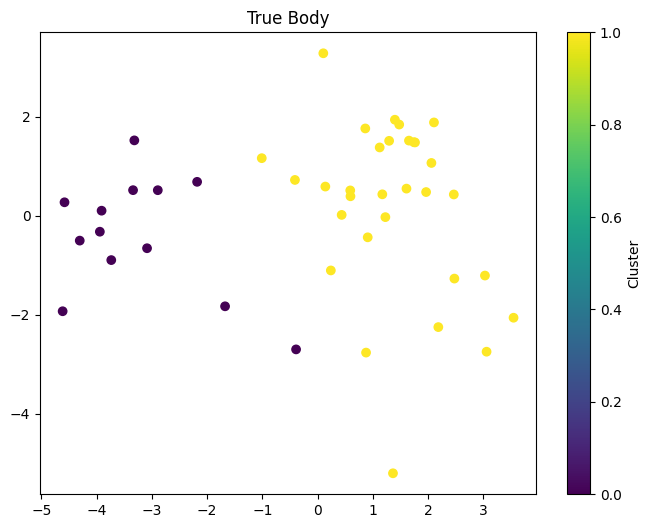

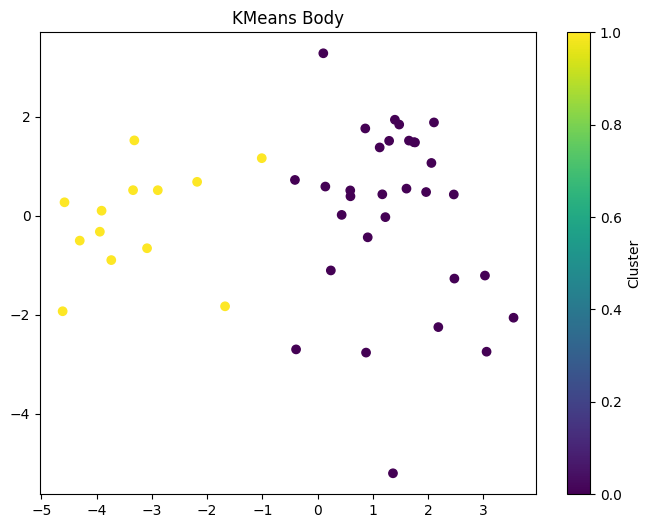

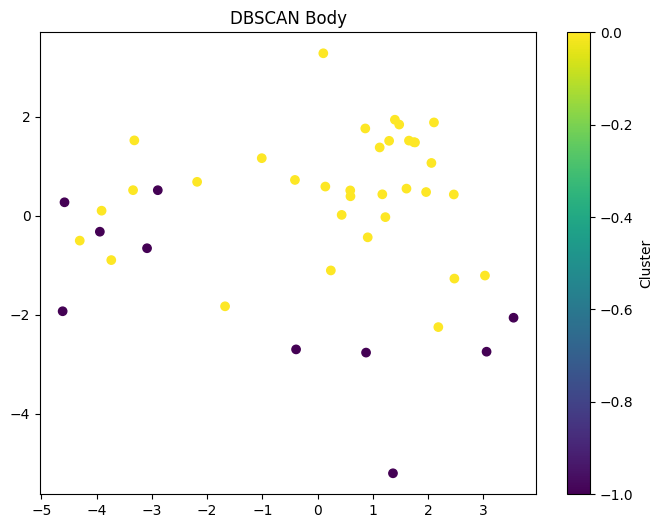

In [ ]:
df_body = df[df["Part"] == "Body"]

X_body, y_body = preprocess_subset(df_body)

k_labels_body, _ = kmeans_pp(X_body, 2)

print("KMeans Silhouette (Body):", silhouette_score(X_body, k_labels_body))
print("KMeans Accuracy (Body):", clustering_accuracy(y_body, k_labels_body))

db_labels_body = dbscan(X_body, eps=3.8, min_samples=3)
print("DBSCAN Silhouette (Body):", silhouette_score(X_body, db_labels_body))

mask = db_labels_body != -1
if np.sum(mask) > 0:
    print("DBSCAN Accuracy (Body):",
          clustering_accuracy(y_body[mask], db_labels_body[mask]))

plot_clusters(X_body, y_body, "True Body")
plot_clusters(X_body, k_labels_body, "KMeans Body")
plot_clusters(X_body, db_labels_body, "DBSCAN Body")

KMeans Silhouette (Glaze): 0.22447157178558322
KMeans Accuracy (Glaze): 0.9090909090909091
DBSCAN Silhouette (Glaze): 0.1919468169938727
DBSCAN Accuracy (Glaze): 0.7575757575757576


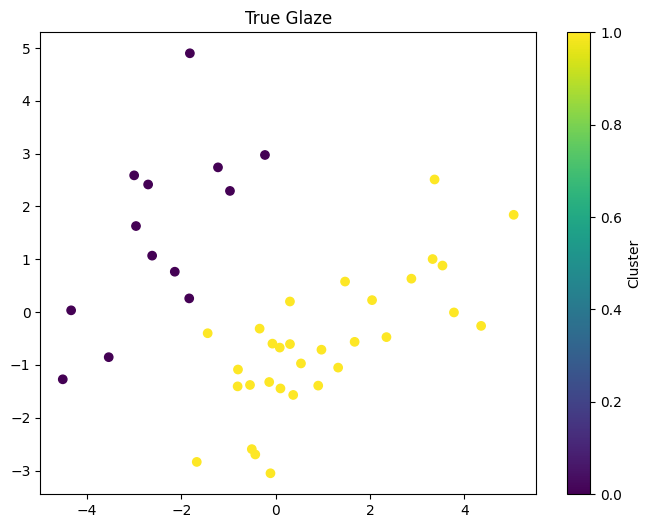

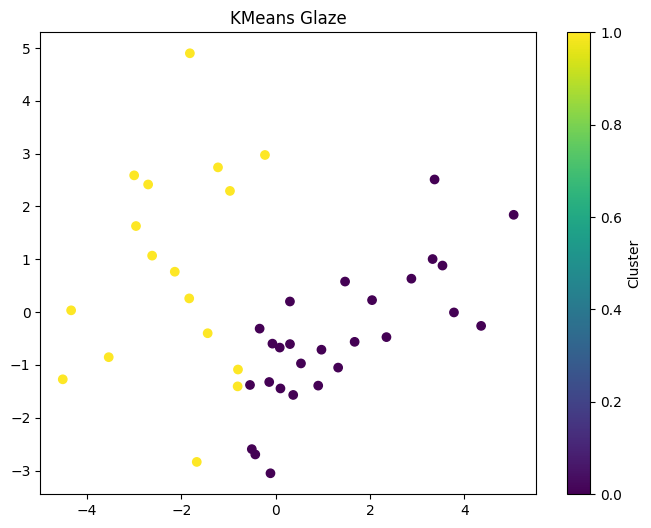

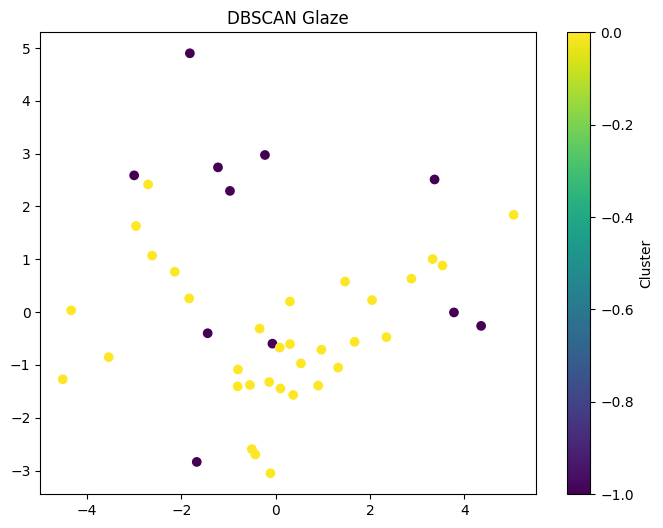

In [ ]:
df_glaze = df[df["Part"] == "Glaze"]

X_glaze, y_glaze = preprocess_subset(df_glaze)

k_labels_glaze, _ = kmeans_pp(X_glaze, 2)

print("KMeans Silhouette (Glaze):", silhouette_score(X_glaze, k_labels_glaze))
print("KMeans Accuracy (Glaze):", clustering_accuracy(y_glaze, k_labels_glaze))

db_labels_glaze = dbscan(X_glaze, eps=3.8, min_samples=3)
print("DBSCAN Silhouette (Glaze):", silhouette_score(X_glaze, db_labels_glaze))

mask = db_labels_glaze != -1
if np.sum(mask) > 0:
    print("DBSCAN Accuracy (Glaze):",
          clustering_accuracy(y_glaze[mask], db_labels_glaze[mask]))

plot_clusters(X_glaze, y_glaze, "True Glaze")
plot_clusters(X_glaze, k_labels_glaze, "KMeans Glaze")
plot_clusters(X_glaze, db_labels_glaze, "DBSCAN Glaze")

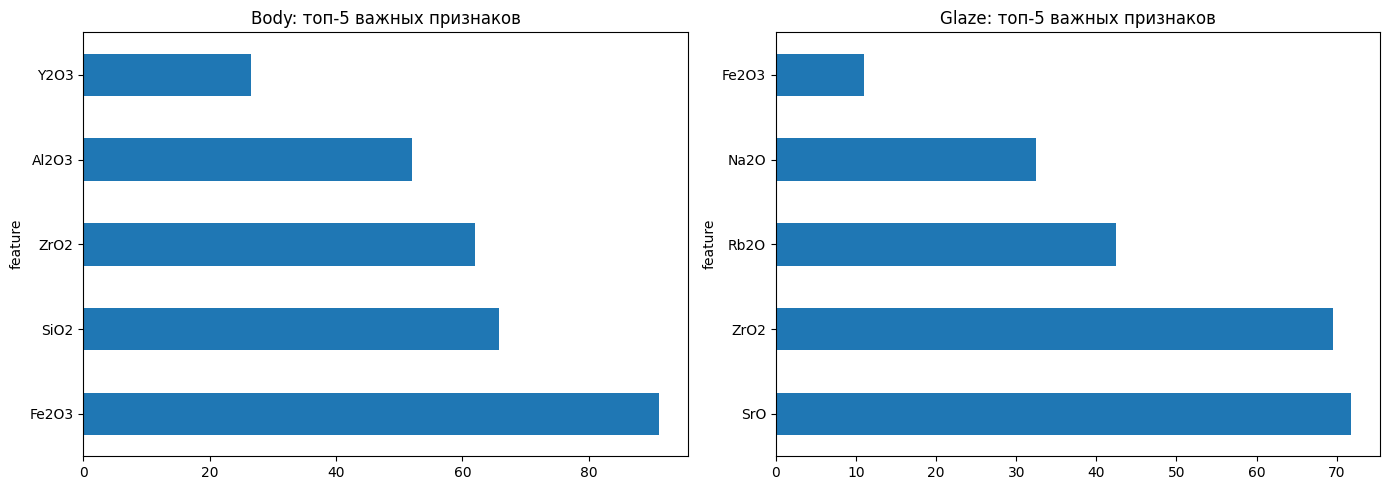

In [ ]:
def analyze_importance(X, labels, feature_names):
    importance = []

    for i, feat in enumerate(feature_names):
        cluster_means = [np.mean(X[labels == c, i]) for c in np.unique(labels) if c != -1]
        overall_mean = np.mean(X[:, i])

        between_var = np.sum([np.sum(labels == c) * (m - overall_mean)**2
                              for c, m in zip(np.unique(labels), cluster_means) if c != -1])
        within_var = np.mean([np.var(X[labels == c, i]) for c in np.unique(labels) if c != -1])

        f_score = between_var / (within_var + 1e-10)
        importance.append((feat, f_score))

    return pd.DataFrame(importance, columns=['feature', 'importance']).sort_values('importance', ascending=False)

feature_names = df_body.drop(columns=["Ceramic Name", "Part"]).columns

body_imp = analyze_importance(X_body, k_labels_body, feature_names)
glaze_imp = analyze_importance(X_glaze, k_labels_glaze, feature_names)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
body_imp.head(5).plot.barh(x='feature', y='importance', ax=axes[0], legend=False)
axes[0].set_title('Body: топ-5 важных признаков')
glaze_imp.head(5).plot.barh(x='feature', y='importance', ax=axes[1], legend=False)
axes[1].set_title('Glaze: топ-5 важных признаков')
plt.tight_layout()
plt.show()